<a href="https://colab.research.google.com/github/JosephBigDataAnalytics/JKaremera-Programming-BigDataAnalytics/blob/main/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 6


Executive Summary


Both models perform comparably on the UCI Credit Card Default dataset. TabPFN edges ahead on the two most critical metrics — Accuracy (81.9% vs 81.4%) and ROC-AUC (0.781 vs 0.765) — indicating better overall ranking of default risk. Random Forest holds a marginal advantage in Macro F1 (0.688 vs 0.681), suggesting slightly better balance across both classes. The most striking contrast is speed: Random Forest trains in 17 seconds but TabPFN trains in just 2.3 seconds using only 10,000 samples. However, TabPFN's inference time is dramatically slower (53.6s vs 0.6s), making Random Forest far more practical for real-time scoring at scale.

Step 0 — Install Dependencies

In [2]:
# Run this once in your terminal or as a notebook cell
!pip install kagglehub tabpfn scikit-learn pandas matplotlib seaborn
!pip install requests==2.32.4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.5
    Uninstalling requests-2.32.5:
      Successfully uninstalled requests-2.32.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tabpfn-common-utils 0.2.18 requires requests>=2.32.5, but you have requests 2.32.4 which is incompatible.


In [2]:
# The pip install in the previous cell appears to have completed successfully.
# If you are encountering a different error, please specify.

Step 1 — Download & Load Dataset

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings("ignore")

dataset_path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
files_in_dataset = os.listdir(dataset_path)
print(f"Files in directory: {files_in_dataset}")

full_csv_path = os.path.join(dataset_path, "UCI_Credit_Card.csv")
df = pd.read_csv(full_csv_path)

print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing values: {df.isnull().sum().sum()} total")
print(f"\nTarget class distribution:\n{df['default.payment.next.month'].value_counts()}")

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Files in directory: ['UCI_Credit_Card.csv']

Dataset shape: (30000, 25)

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AM

Step 2 — Preprocessing

In [4]:
from sklearn.preprocessing import StandardScaler

# Drop non-informative ID column
df = df.drop(columns=["ID"])

TARGET = "default.payment.next.month"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Class balance → 0 (No Default): {(y==0).sum()} | 1 (Default): {(y==1).sum()}")

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("\nFeatures scaled successfully.")


Features shape: (30000, 23)
Target shape:   (30000,)
Class balance → 0 (No Default): 23364 | 1 (Default): 6636

Features scaled successfully.


Step 3 — Train / Test Split (75% / 25%)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")


Training set:  22500 samples
Test set:      7500 samples


Step 4 — Train & Evaluate Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix
)

print("Training Random Forest...")
rf_start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - rf_start
print(f"Training time: {rf_train_time:.2f}s")

# Predictions
rf_start_pred = time.time()
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred_time = time.time() - rf_start_pred

rf_acc      = accuracy_score(y_test, rf_preds)
rf_auc      = roc_auc_score(y_test, rf_proba)
rf_f1       = f1_score(y_test, rf_preds, average="weighted")
rf_f1_macro = f1_score(y_test, rf_preds, average="macro")

print(f"\n--- Random Forest Results ---")
print(f"Accuracy:       {rf_acc:.4f}")
print(f"ROC-AUC:        {rf_auc:.4f}")
print(f"F1 (Weighted):  {rf_f1:.4f}")
print(f"F1 (Macro):     {rf_f1_macro:.4f}")
print(f"Inference time: {rf_pred_time:.4f}s")
print(f"\nClassification Report:\n{classification_report(y_test, rf_preds)}")


Training Random Forest...
Training time: 17.02s

--- Random Forest Results ---
Accuracy:       0.8136
ROC-AUC:        0.7648
F1 (Weighted):  0.7983
F1 (Macro):     0.6877
Inference time: 0.6095s

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      5841
           1       0.62      0.40      0.49      1659

    accuracy                           0.81      7500
   macro avg       0.73      0.67      0.69      7500
weighted avg       0.80      0.81      0.80      7500



Step 5 — Train & Evaluate TabPFN

In [25]:
import torch
from tabpfn import TabPFNClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report
)
import time

# Auto-detect GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

TABPFN_TRAIN_LIMIT = 10_000  # Keep your original 10k limit — GPU handles this fine

if len(X_train) > TABPFN_TRAIN_LIMIT:
    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_train, y_train,
        train_size=TABPFN_TRAIN_LIMIT,
        stratify=y_train,
        random_state=42
    )
    print(f"TabPFN training subset: {TABPFN_TRAIN_LIMIT} samples (of {len(X_train)} total)")
else:
    X_train_sub, y_train_sub = X_train, y_train

print("Training TabPFN...")
tab_start = time.time()

try:
    tabpfn_model = TabPFNClassifier(
        device=device,       # ← Now uses GPU automatically
        n_estimators=8,
        random_state=42,
        model_path=tabpfn_model_path # Pass the manually downloaded model path
    )
    tabpfn_model.fit(X_train_sub.values, y_train_sub.values)
    tab_train_time = time.time() - tab_start
    print(f"Training time: {tab_train_time:.2f}s")

    # Predictions on full test set
    tab_start_pred = time.time()
    tab_preds = tabpfn_model.predict(X_test.values)
    tab_proba = tabpfn_model.predict_proba(X_test.values)[:, 1]
    tab_pred_time = time.time() - tab_start_pred

    tab_acc      = accuracy_score(y_test, tab_preds)
    tab_auc      = roc_auc_score(y_test, tab_proba)
    tab_f1       = f1_score(y_test, tab_preds, average="weighted")
    tab_f1_macro = f1_score(y_test, tab_preds, average="macro")

    print(f"\n--- TabPFN Results ---")
    print(f"Accuracy:       {tab_acc:.4f}")
    print(f"ROC-AUC:        {tab_auc:.4f}")
    print(f"F1 (Weighted):  {tab_f1:.4f}")
    print(f"F1 (Macro):     {tab_f1_macro:.4f}")
    print(f"Inference time: {tab_pred_time:.4f}s")
    print(f"\nClassification Report:\n{classification_report(y_test, tab_preds)}")

except Exception as e:
    print("\n--- ERROR TRAINING TABPFN ---")
    print("TabPFN failed during training or prediction.")
    print(f"Error details: {e}")
    # Initialize metrics to default values to avoid NameError in subsequent cells
    tab_acc = tab_auc = tab_f1 = tab_f1_macro = 0.0
    tab_train_time = tab_pred_time = 0.0
    tab_preds = None
    tab_proba = None

Using device: cuda
TabPFN training subset: 10000 samples (of 22500 total)
Training TabPFN...
Training time: 2.35s

--- TabPFN Results ---
Accuracy:       0.8189
ROC-AUC:        0.7812
F1 (Weighted):  0.7980
F1 (Macro):     0.6810
Inference time: 53.6528s

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      5841
           1       0.67      0.36      0.47      1659

    accuracy                           0.82      7500
   macro avg       0.75      0.66      0.68      7500
weighted avg       0.80      0.82      0.80      7500



In [22]:
tabpfn_model_path = "/content/tabpfn-v2.5-classifier-v2.5_default.ckpt" # @param {type:"string"}
print(f"TabPFN model path set to: {tabpfn_model_path}")

TabPFN model path set to: /content/tabpfn-v2.5-classifier-v2.5_default.ckpt


In [21]:
from tabpfn import TabPFNClassifier

# TabPFN will auto-download the checkpoint on first use
clf = TabPFNClassifier()
print("Model loaded successfully!")


Model loaded successfully!


Step 6 — Side-by-Side Comparison Table

In [26]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy", "ROC-AUC", "F1 (Weighted)", "F1 (Macro)",
        "Train Time (s)", "Inference Time (s)"
    ],
    "Random Forest": [
        rf_acc, rf_auc, rf_f1, rf_f1_macro,
        round(rf_train_time, 2), round(rf_pred_time, 4)
    ],
    "TabPFN": [
        tab_acc, tab_auc, tab_f1, tab_f1_macro,
        round(tab_train_time, 2), round(tab_pred_time, 4)
    ]
})

print("=" * 55)
print("           MODEL COMPARISON TABLE")
print("=" * 55)
print(results.to_string(index=False))

           MODEL COMPARISON TABLE
            Metric  Random Forest    TabPFN
          Accuracy       0.813600  0.818933
           ROC-AUC       0.764783  0.781234
     F1 (Weighted)       0.798266  0.797954
        F1 (Macro)       0.687699  0.680975
    Train Time (s)      17.020000  2.350000
Inference Time (s)       0.609500 53.652800


Step 7 — Visualisations (6-Panel Plot)

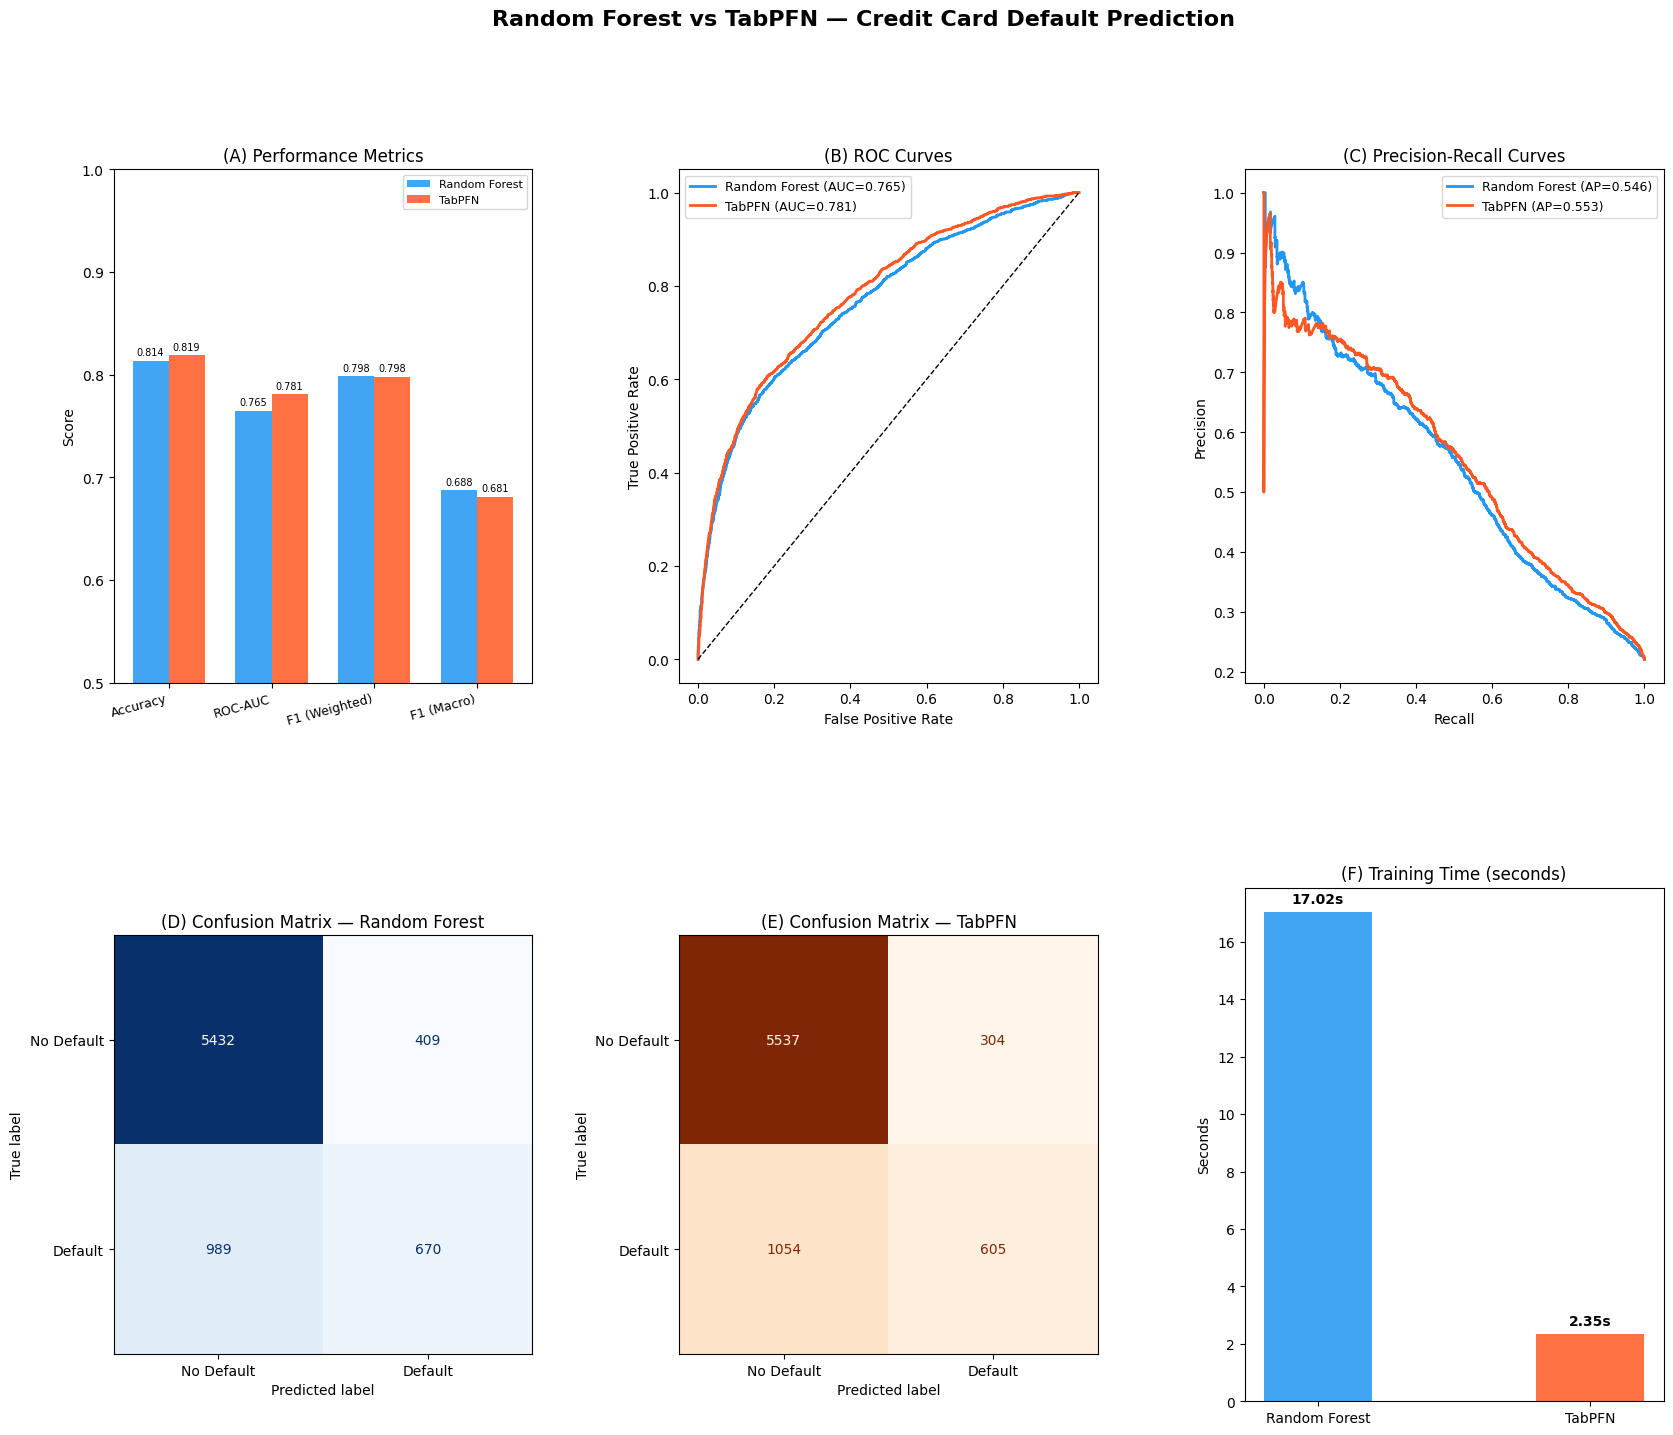

Saved: rf_vs_tabpfn_comparison.png


In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score

PALETTE = {"Random Forest": "#2196F3", "TabPFN": "#FF5722"}

fig = plt.figure(figsize=(20, 16))
fig.suptitle("Random Forest vs TabPFN — Credit Card Default Prediction",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# (A) Bar chart — core metrics
ax1 = fig.add_subplot(gs[0, 0])
metrics_labels = ["Accuracy", "ROC-AUC", "F1 (Weighted)", "F1 (Macro)"]
rf_vals  = [rf_acc, rf_auc, rf_f1, rf_f1_macro]
tab_vals = [tab_acc, tab_auc, tab_f1, tab_f1_macro]
x = np.arange(len(metrics_labels))
width = 0.35
bars1 = ax1.bar(x - width/2, rf_vals,  width, label="Random Forest",
                color=PALETTE["Random Forest"], alpha=0.85)
bars2 = ax1.bar(x + width/2, tab_vals, width, label="TabPFN",
                color=PALETTE["TabPFN"], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_labels, rotation=15, ha="right", fontsize=9)
ax1.set_ylim(0.5, 1.0)
ax1.set_ylabel("Score")
ax1.set_title("(A) Performance Metrics")
ax1.legend(fontsize=8)
for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

# (B) ROC Curves
ax2 = fig.add_subplot(gs[0, 1])
for name, proba, color in [("Random Forest", rf_proba, PALETTE["Random Forest"]),
                             ("TabPFN",        tab_proba, PALETTE["TabPFN"])]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_val:.3f})")
ax2.plot([0,1],[0,1], "k--", lw=1)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("(B) ROC Curves")
ax2.legend(fontsize=9)

# (C) Precision-Recall Curves
ax3 = fig.add_subplot(gs[0, 2])
for name, proba, color in [("Random Forest", rf_proba, PALETTE["Random Forest"]),
                             ("TabPFN",        tab_proba, PALETTE["TabPFN"])]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax3.plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.set_title("(C) Precision-Recall Curves")
ax3.legend(fontsize=9)

# (D) Confusion Matrix — Random Forest
ax4 = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_preds),
                       display_labels=["No Default", "Default"]).plot(
    ax=ax4, colorbar=False, cmap="Blues")
ax4.set_title("(D) Confusion Matrix — Random Forest")

# (E) Confusion Matrix — TabPFN
ax5 = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(confusion_matrix(y_test, tab_preds),
                       display_labels=["No Default", "Default"]).plot(
    ax=ax5, colorbar=False, cmap="Oranges")
ax5.set_title("(E) Confusion Matrix — TabPFN")

# (F) Training Time
ax6 = fig.add_subplot(gs[1, 2])
models = ["Random Forest", "TabPFN"]
times  = [rf_train_time, tab_train_time]
colors = [PALETTE["Random Forest"], PALETTE["TabPFN"]]
bars   = ax6.bar(models, times, color=colors, alpha=0.85, width=0.4)
ax6.set_ylabel("Seconds")
ax6.set_title("(F) Training Time (seconds)")
for bar, t in zip(bars, times):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{t:.2f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.savefig("rf_vs_tabpfn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_vs_tabpfn_comparison.png")

Step 8 — Feature Importance (Random Forest)

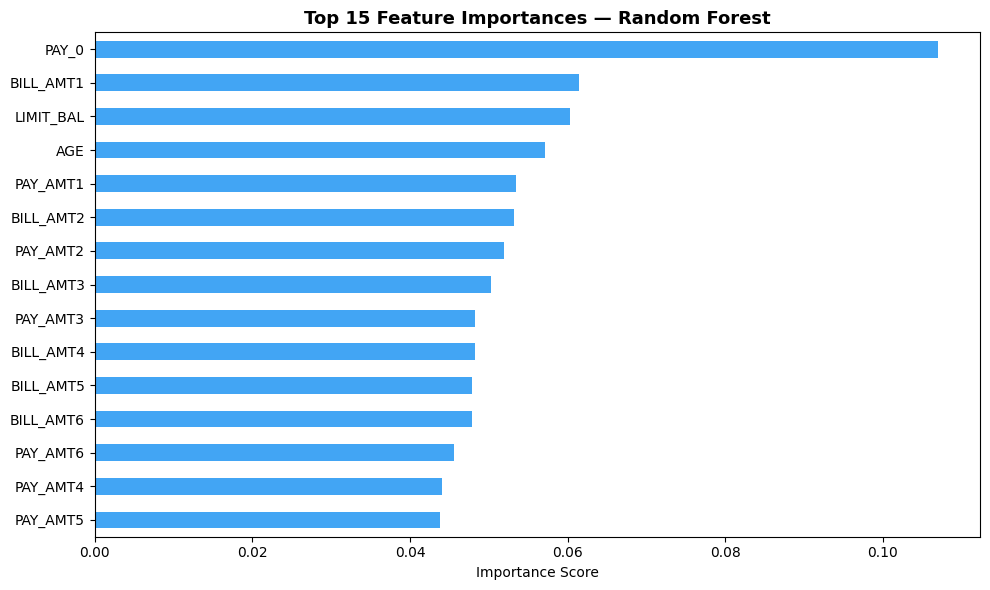

Saved: rf_feature_importance.png


In [28]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = feat_imp.nlargest(15)

fig2, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="#2196F3", alpha=0.85)
ax.set_title("Top 15 Feature Importances — Random Forest",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_feature_importance.png")


Step 9 — Save Results to CSV

In [29]:
results.to_csv("model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")
print("\n✅ All steps complete!")


Saved: model_comparison_results.csv

✅ All steps complete!
